In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RESULTS = PROJECT_ROOT / "database" / "results.parquet"

In [ ]:
import sys

repo_root = Path.cwd().resolve()

if (repo_root / "utils").exists() is False:
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))

from utils.single_strategy_runner import run_single_strategy


In [6]:
import pandas as pd

df = pd.read_parquet(RESULTS)

AttributeError: module 'pandas' has no attribute 'core'

In [5]:
df.to_csv("non_ml_results.csv")

In [5]:
out = run_single_strategy(
    strategy_name="INSIDE_BAR_CONT",
    symbol="USO",
    interval="1d",
    param_dict={"atr_len": 14, "max_hold_bars": 60, "slope_lookback": 5, "stop_atr": 1.5, "trend_len": 50},
)

In [6]:
import json

def row_run(df_row):
    res = run_single_strategy(
        strategy_name=df_row["strategy"],
        symbol=df_row["symbol"],
        interval=df_row["interval"],
        param_dict=json.loads(df_row["parameters"]),
    )
    return res

In [9]:
best = df.sort_values(by="return", ascending=False).head(5).values.tolist()
res = []

for i in best:
    row_dict = dict(zip(df.columns, i))
    res.append(row_run(row_dict))

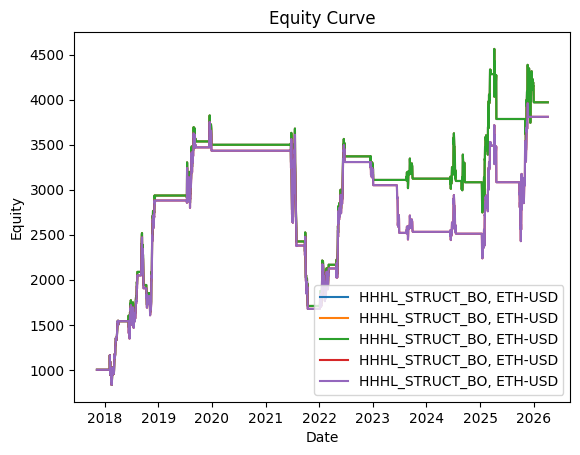

In [10]:
import matplotlib.pyplot as plt

for i in range(len(res)):
    plt.plot(res[i]['equity_curve']['equity'], label=f"{best[i][0]}, {best[i][1]}")


plt.title('Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')


plt.legend()
plt.show()


In [4]:
df.groupby("strategy", as_index=False)[["return", "excess_return", "sharpe"]].mean().sort_values(by=["excess_return"], ascending=False)

,strategy,return,excess_return,sharpe
0,ATR_VOL_BO,2.064907,-3111.316535,-0.535901
11,SMC_SWEEP_OBFVG,0.064509,-3113.316933,-0.629452
10,RSI_PULLBACK,-2.592935,-3115.974377,-0.282539
1,BBANDS_MR,-3.511191,-3116.892633,-1.432008
12,VWAP_RECLAIM,-17.481054,-3130.862495,-0.313933
9,RSI_MA,-19.859860,-3133.241302,-0.555268
7,MA200_PULLBACK,-21.634858,-3135.016300,-0.174608
5,HHHL_STRUCT_BO,-21.916137,-3135.297579,-0.213160
6,INSIDE_BAR_CONT,-24.265005,-3137.646447,-0.270062
2,DMAC,-33.349511,-3146.730953,-0.313859


In [6]:
top100 = df.sort_values(by=["excess_return"], ascending=False).head(100)
top100.groupby("interval", as_index=True)[["excess_return", "sharpe"]].median().sort_values(by=["excess_return"], ascending=False)

,excess_return,sharpe
interval,,
1d,105.610108,0.064924


In [7]:
summary = (
    df.groupby(["strategy", "parameters"], as_index=False)
      .agg(
          return_mean=("return", "mean"),
          excess_return_mean=("excess_return", "mean"),
          sharpe_mean=("sharpe", "mean"),
          trades_mean=("trades", "mean"),
      )
      .sort_values(["strategy", "return_mean"], ascending=[True, False])
)

summary.sort_values(by=["excess_return_mean"], ascending=False)


,strategy,parameters,return_mean,excess_return_mean,sharpe_mean,trades_mean
53,DMAC,"{""adx_period"": 7, ""adx_threshold"": 20, ""pfast""...",44.188701,-1087.539510,-6.244226,12.857143
57,DMAC,"{""adx_period"": 7, ""adx_threshold"": 20, ""pfast""...",43.816943,-1087.911268,-9.436730,10.238095
45,DMAC,"{""adx_period"": 14, ""adx_threshold"": 20, ""pfast...",37.730007,-1093.998205,-6.946675,10.357143
49,DMAC,"{""adx_period"": 14, ""adx_threshold"": 20, ""pfast...",37.728513,-1093.999698,-9.793023,8.642857
68,DONCHIAN_BO,"{""atr_len"": 14, ""cooldown_bars"": 5, ""entry_buf...",32.946627,-1098.781585,-5.643121,59.857143
...,...,...,...,...,...,...
248,RSI_MA,"{""buy_rsi"": 50, ""ma"": 200, ""sell_rsi"": 40}",-3.138710,-1134.866921,-9.467555,348.071429
251,RSI_MA,"{""buy_rsi"": 50, ""ma"": 50, ""sell_rsi"": 35}",-3.712799,-1135.441011,-13.026905,267.833333
247,RSI_MA,"{""buy_rsi"": 50, ""ma"": 200, ""sell_rsi"": 35}",-3.929681,-1135.657892,-9.988529,403.095238
244,RSI_MA,"{""buy_rsi"": 50, ""ma"": 100, ""sell_rsi"": 40}",-4.021073,-1135.749284,-10.633828,323.857143


In [8]:
positive_excess_15m = df[(df["excess_return"] > 0) & (df["interval"] == "15m")].copy()
interval_15m = df[df["interval"] == "15m"].copy()

interval_15m.groupby("strategy", as_index=False)[["return", "excess_return", "sharpe"]].mean().sort_values(by=["excess_return"], ascending=False)

,strategy,return,excess_return,sharpe
3,DONCHIAN_BO,1.461545,-0.804796,-17.466451
9,RSI_MA,0.519838,-1.746502,-65.038037
5,HHHL_STRUCT_BO,0.256846,-2.009495,-22.038059
2,DMAC,0.155857,-2.110484,-21.186096
4,EMA_ACCEL_BO,0.027074,-2.239267,-15.769415
11,SMC_SWEEP_OBFVG,0.006814,-2.259527,-325.087242
0,ATR_VOL_BO,-0.060236,-2.326576,-91.228724
1,BBANDS_MR,-0.090825,-2.357166,-166.808747
10,RSI_PULLBACK,-0.328140,-2.594481,-57.583373
7,MA200_PULLBACK,-0.357029,-2.623370,-16.430276


In [73]:
reg = df[(df["excess_return"] != 0) & (df["win_rate"] != 0) & (df["win_rate"] < 1) & (df["return"] < 80) & (df["win_rate"] > 0)]

reg = reg.sort_values(by=["sharpe"], ascending=False).head(6000)

C:\Users\ruben\AppData\Local\Temp\ipykernel_4016\2907288350.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


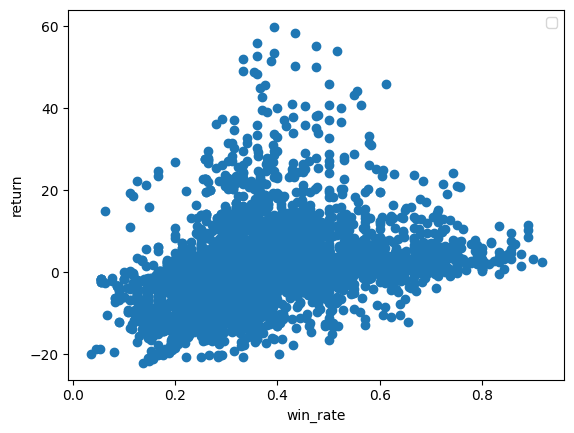

In [75]:
import matplotlib.pyplot as plt

x = "win_rate"
y = "return"

plt.scatter(reg[x], reg[y])

plt.xlabel(x)
plt.ylabel(y)

plt.legend()
plt.show()

In [ ]:
reg[[x,y]].to_csv("regression.csv")

: 